In [ ]:
%pip install astropy astroquery matplotlib numpy photutils

In [1]:
import numpy

import astropy.units as u

from astropy.io import fits
from astropy.wcs import WCS

from astroquery.simbad import Simbad
# from astroquery.astrometry_net import AstrometryNet

import matplotlib.pyplot as plot

%matplotlib inline

In [15]:
filepath = '/Users/finny/Documents/Exoplanets/Exoplanet Data/2025/March 2025/TRES3_2013SEPTEMBER16/MOBS_Cecilia_TRES-2_2015-09-04T20_43_35.037-0700_319f0ebff40ad43f48007daf2046ab5b_TRES-2150905042412.FITS'
star_name = 'TRES-2'

# NOTE: Get these values by uploading directly to astrometry.net and not their API.
# Their API gives incorrect values, possible because of the photoutil instead of direct upload.
ra, dec = (286.748, 49.381)

# ast = AstrometryNet()
# ast.api_key = 'nxwozpawpmlduuts'

In [16]:
# Get image data

hdul = fits.open(filepath)
header = hdul[0].header
image_data = hdul[0].data

image_scale = header.get('IM_SCALE', 5.21)  # Default to 5.21 if missing
print(image_scale)

# Extract WCS information
wcs = WCS(header)
hdul.close()

print(wcs)

# result = ast.solve_from_image(filepath, arcsecperpix = image_scale, force_image_upload = True)
#
# ra = result['CRVAL1']
# dec = result['CRVAL2']
#
# print(ra, dec)

5.21
WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 650  500


Set MJD-END to 57269.892529 from DATE-END'. [astropy.wcs.wcs]


In [17]:
# Get the image dimensions

image_shape = (header['NAXIS1'], header['NAXIS2'])
center_pixel = numpy.array([[image_shape[0] / 2, image_shape[1] / 2]])
print(center_pixel)

[[325. 250.]]


In [18]:
# Find the desired star

simbad = Simbad()
result = simbad.query_object(star_name)

ra_star = result['ra'][0]  # Right Ascension
dec_star = result['dec'][0]  # Declination

print(ra_star, dec_star)

286.80848993188 49.3164143006


(27, -44)
(297, 294)
(297, 205)


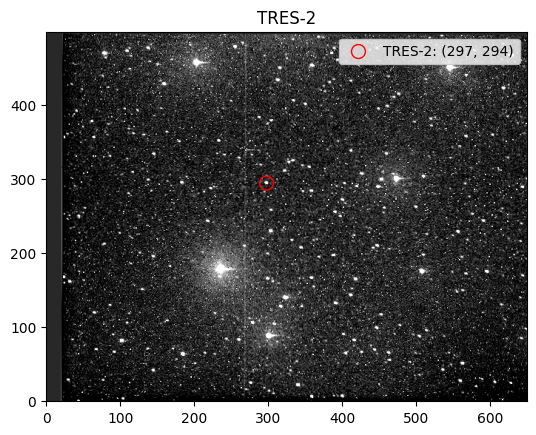

In [44]:
# Get the star pixel & plot

x_center = image_shape[0] / 2
y_center = image_shape[1] / 2

# Convert RA/DEC to pixel coordinates
delta_ra = (ra_star - ra)
delta_dec = (dec_star - dec)

delta_x_pixel = ((delta_ra * u.deg).value * 3600 / image_scale) * numpy.cos(numpy.radians(dec_star))
delta_y_pixel = (delta_dec * u.deg).value * 3600 / image_scale

# because they are reversed
x_pixel = x_center - delta_x_pixel
y_pixel = y_center - delta_y_pixel # exotic has lower origin
# y_pixel = int(image_shape[1] - y_pixel)

print((int(delta_x_pixel), int(delta_y_pixel)))
print((int(x_pixel), int(y_pixel)))
print((int(x_pixel), int(image_shape[1] - y_pixel)))

# Plot the FITS image with overlayed stars
plot.imshow(image_data, cmap = 'gray', origin = 'lower', vmin = numpy.percentile(image_data, 15), vmax = numpy.percentile(image_data, 98.9))
plot.scatter(x_pixel, y_pixel, color = 'none', edgecolor = 'red', s = 100, marker = 'o', label = f'{star_name}: ({int(x_pixel)}, {int(y_pixel)})')

plot.legend()
plot.title(star_name)

plot.show()